# Import bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset

In [2]:
dados_relat = pd.read_csv('base_dados_derivada_min.csv')

# Análise explanatória dos dados

In [3]:
dados_relat.head()

,npf,quarto_jg,vel_max,adversario,idade,classificacao,interv_dias,mando,posicao,dif,...,dai_min,dmi_min,aci_min,acmi_min,ac_total_min,dci_min,dcmi_min,dc_total_min,dif_duo,interv_duo
0,709286,2,26.9,flameng,28,3,NaN,2,1,-12,...,34.489796,74.081633,5.918367,20.816327,31.224490,5.714286,22.244898,33.673469,1,1
1,703092,3,27.0,flameng,27,3,NaN,2,3,-12,...,29.677419,63.548387,3.870968,18.709677,29.032258,6.451613,19.032258,30.967742,1,1
2,709286,3,26.7,flameng,28,3,NaN,2,1,-12,...,26.000000,67.200000,6.500000,18.300000,23.500000,6.000000,20.300000,26.800000,1,1
3,709202,2,25.6,flameng,20,3,NaN,2,1,-12,...,25.263158,55.263158,5.789474,29.473684,42.105263,5.789474,29.473684,42.631579,1,1
4,709286,4,27.9,flameng,28,3,NaN,2,1,-12,...,23.800000,63.500000,5.100000,16.200000,22.700000,5.200000,16.500000,24.700000,1,1


In [4]:
dados_relat['interv_dias'].isnull().sum()

np.int64(67)

In [5]:
dados_relat.shape

(4628, 45)

In [6]:
dados_relat.trimp_min.describe()

,trimp_min
count,4628.000000
mean,10.567118
std,4.527803
min,0.000000
25%,7.906977
50%,9.575966
75%,11.935484
max,61.428571


In [7]:
dados_relat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 45 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   npf             4628 non-null   int64  
 1   quarto_jg       4628 non-null   int64  
 2   vel_max         4628 non-null   float64
 3   adversario      4628 non-null   object 
 4   idade           4628 non-null   int64  
 5   classificacao   4628 non-null   int64  
 6   interv_dias     4561 non-null   float64
 7   mando           4628 non-null   int64  
 8   posicao         4628 non-null   int64  
 9   dif             4628 non-null   int64  
 10  nome_sessao     4628 non-null   object 
 11  tempo           4628 non-null   float64
 12  temp            4628 non-null   object 
 13  sprints         4628 non-null   float64
 14  zv1_min         4628 non-null   float64
 15  zv2_min         4628 non-null   float64
 16  zv3_min         4628 non-null   float64
 17  zv4_min         4628 non-null   f

# Análise exploratória dos dados

In [8]:
dados_relat.isnull().sum()

,0
npf,0
quarto_jg,0
vel_max,0
adversario,0
idade,0
classificacao,0
interv_dias,67
mando,0
posicao,0
dif,0


In [9]:
dados_relat.dropna(inplace=True)

In [10]:
dados_relat['interv_dias'].isnull().sum()

np.int64(0)

In [11]:
dados_relat.shape

(4561, 45)

In [12]:
dados_relat.columns

Index(['npf', 'quarto_jg', 'vel_max', 'adversario', 'idade', 'classificacao',
       'interv_dias', 'mando', 'posicao', 'dif', 'nome_sessao', 'tempo',
       'temp', 'sprints', 'zv1_min', 'zv2_min', 'zv3_min', 'zv4_min',
       'zv5_min', 'dcel1_min', 'dcel2_min', 'dcel3_min', 'dcel4_min',
       'acel1_min', 'acel2_min', 'acel3_min', 'acel4_min', 'fc1_min',
       'fc2_min', 'fc3_min', 'fc4_min', 'fc5_min', 'fc_80_min', 'trimp_min',
       'dits_total_min', 'dai_min', 'dmi_min', 'aci_min', 'acmi_min',
       'ac_total_min', 'dci_min', 'dcmi_min', 'dc_total_min', 'dif_duo',
       'interv_duo'],
      dtype='object')

## Descrição das variaveis:

- npf: numero de matrícula do atleta

- nome_sessao: codigo do jogo

- quarto_jg: quarto do jogo (1°, 2°, 3° e 4°)

- vel_max: velocidade máxima (em km/h)

- sprint: n° de vezes que o jogador passa 24km/h

- zv1: Distancia percorrida 3 - 6 km/h

- zv2: Distancia percorrida 6,01 - 12 km/h

- zv3: Distancia percorrida 12,01 - 18 km/h

- zv4: Distancia percorrida 18,01 - 24 km/h

- zv5: Distancia percorrida 24,01+ km/h

- dmi: Distancia percorrida 12,01+ km/h (Soma da zv3, zv4 e zv5)

- dai: Distancia percorrida 18,01+ km/h (Soma da zv4 e zv5)

- dcel1: -0.50 – -0.99 [m/s²]

- dcel2: -1.00 – -1.99 [m/s²]

- dcel3: -2.00 – -2.99 [m/s²]

- dcel4: -3.00 – -50.00 [m/s²]

- acel1: 0.50 – 0.99 [m/s²]

- acel2: 1.00 – 1.99 [m/s²]

- acel3: 2.00 – 2.99 [m/s²]

- acel4: 3.00 – 50.00 [m/s²]

- fc1: Tempo de permanecia entre 50 - 59% da FC máx do atleta

- fc2: Tempo de permanecia entre 60 - 69% da FC máx do atleta

- fc3: Tempo de permanecia entre 70 - 79% da FC máx do atleta

- fc4: Tempo de permanecia entre 80 - 89% da FC máx do atleta

- fc5: Tempo de permanecia entre 90 - 100% da FC máx do atleta

- fc_80: Tempo de permanecia entre 80 - 100% da FC máx do atleta (Soma de fc4 e fc5)

- trimp: Indice de estresse cardiovascular. Pondera o tempo em cada zona de FC pelo peso da zona (TRIMP = (fc1 * 1) + (fc2 * 2) + (fc3 * 3) + (fc4 * 4) + (fc5 * 5))

- adversario: Nome do adversário na partida

- idade: Idade do jogador no dia da partida

- classificacao: Classificação do time ao final do campeonato

- interv_dias: Intervalo de dias da partida atual em relação à anterior

- mando: Jogos realizados em casa (mando 2) e na casa do adversário (mando 1)

- posicao: Posição do atleta na equipe, sendo: Ala = 1, Pivô = 2 e Armador = 3

- dif: Diferença no placar final do jogo

- tempo: Tempo de permanencia em quadra

<Axes: xlabel='trimp_min', ylabel='dai_min'>

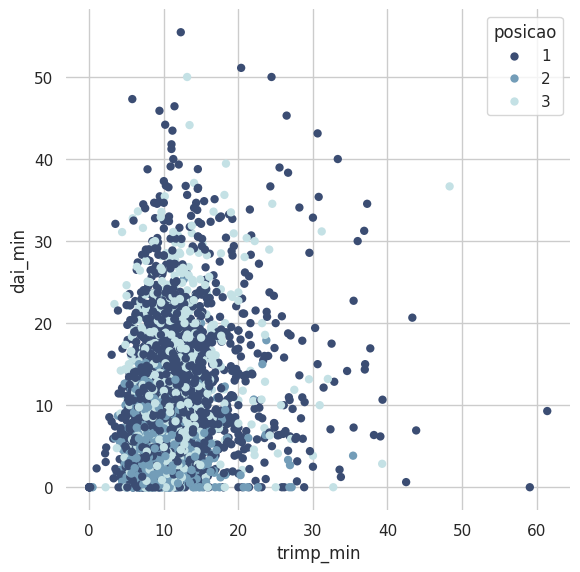

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Draw a scatter plot while assigning point colors and sizes to different
# variables in the dataset
f, ax = plt.subplots(figsize=(6.5, 6.5))
sns.despine(f, left=True, bottom=True)
sns.scatterplot(x="trimp_min", y="dai_min",
                hue="posicao",
                palette="ch:r=-.2,d=.3_r",
                sizes=(1, 8), linewidth=0,
                data=dados_relat, ax=ax)

In [14]:
cont = (dados_relat['interv_dias']).value_counts()
cont

,count
interv_dias,
2.0,1484
3.0,925
4.0,584
5.0,380
7.0,239
6.0,225
8.0,176
9.0,147
10.0,137


In [15]:
mapa_posicoes = {
    1: 'Ala',
    2: 'Pivo',
    3: 'Armador'
}
dados_relat['posicao'] = dados_relat['posicao'].map(mapa_posicoes)

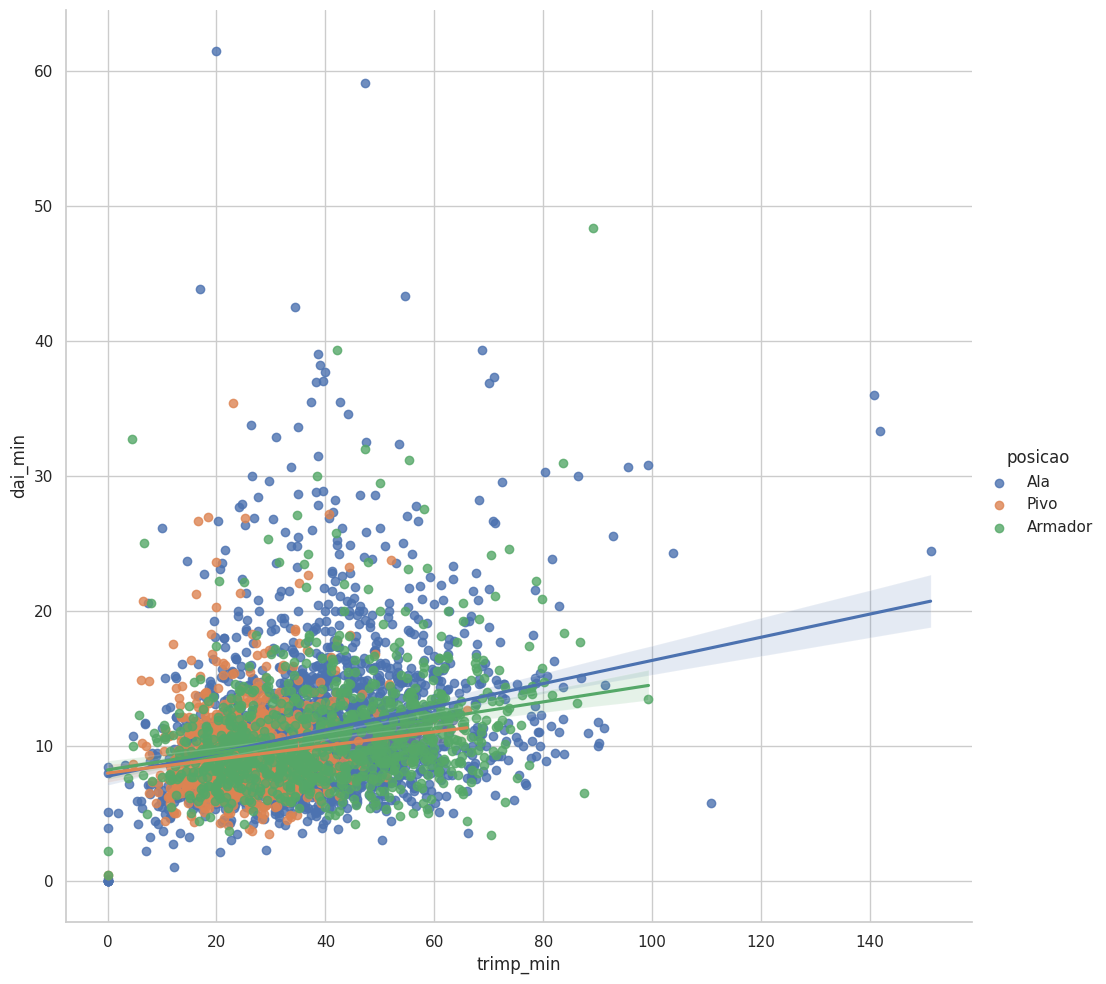

In [16]:
sns.set_theme(style="whitegrid")

# Plot sepal width as a function of sepal_length across days
g = sns.lmplot(
    data=dados_relat,
    x="dmi_min", y="trimp_min",
                hue="posicao",
    palette="deep",
    height=10
)

# Use more informative axis labels than are provided by default
g.set_axis_labels("trimp_min", "dai_min")

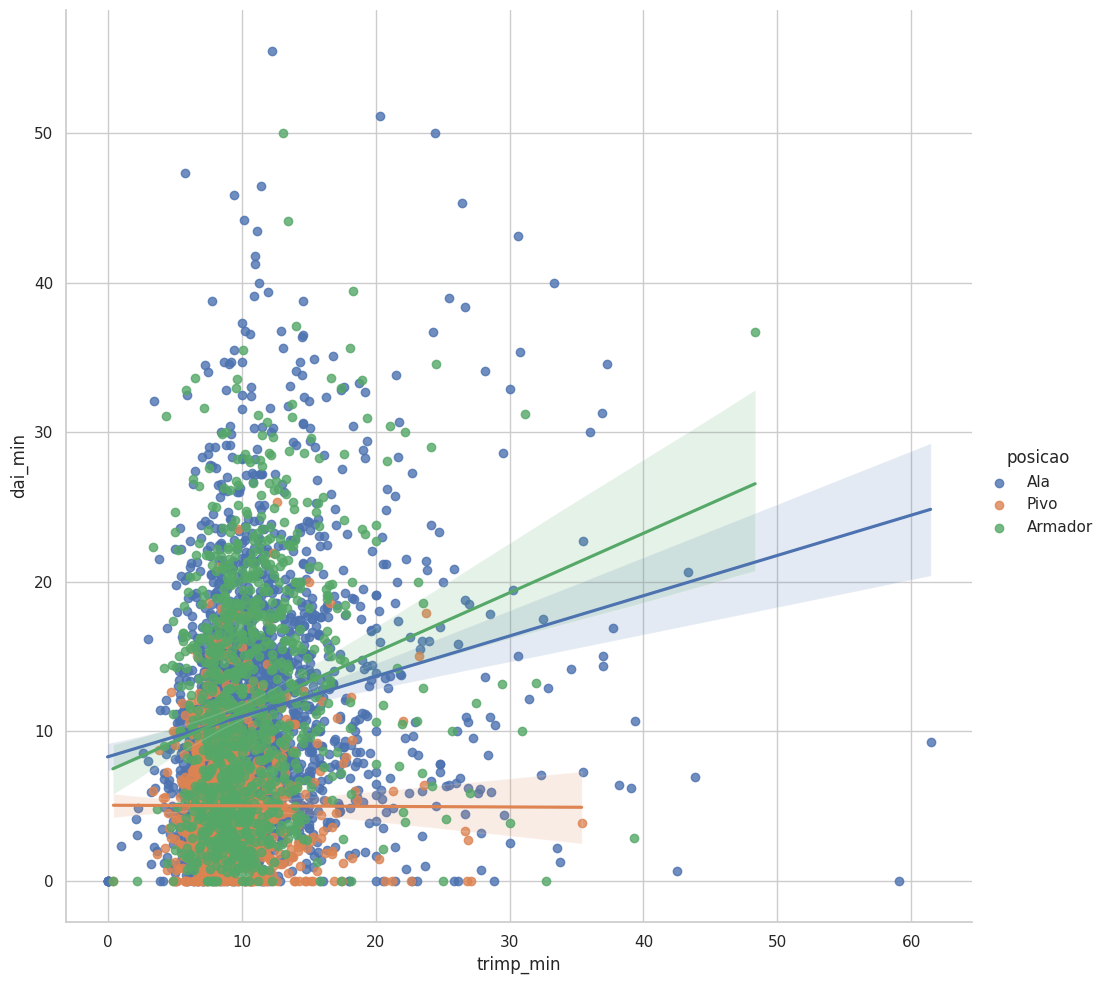

In [17]:
sns.set_theme(style="whitegrid")

# Plot sepal width as a function of sepal_length across days
g = sns.lmplot(
    data=dados_relat,
    x="trimp_min", y="dai_min",
                hue="posicao",
    palette="deep",
    height=10
)

# Use more informative axis labels than are provided by default
g.set_axis_labels("trimp_min", "dai_min")

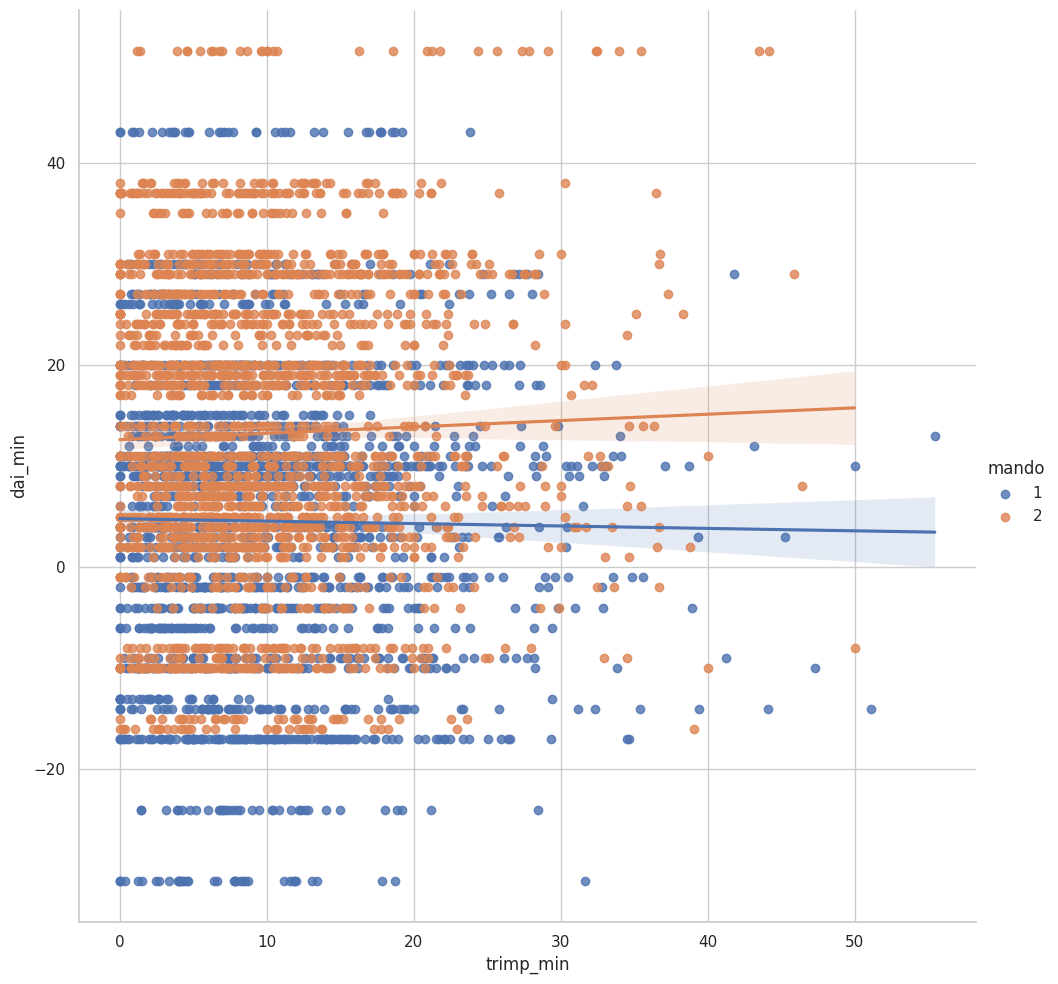

In [18]:
sns.set_theme(style="whitegrid")

# Plot sepal width as a function of sepal_length across days
g = sns.lmplot(
    data=dados_relat,
    x="dai_min", y="dif",
                hue="mando",
    palette="deep",
    height=10
)

# Use more informative axis labels than are provided by default
g.set_axis_labels("trimp_min", "dai_min")

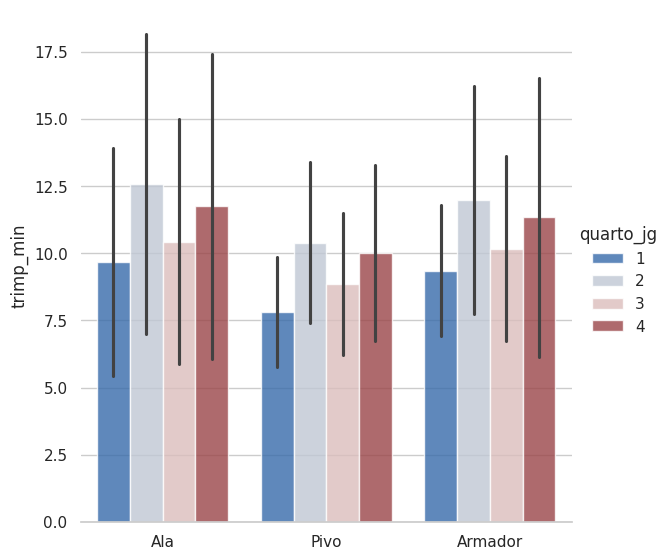

In [19]:
import seaborn as sns
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="bar",
    x="posicao", y="trimp_min", hue="quarto_jg",
    errorbar="sd", palette="vlag", alpha=.8, height=6
)
g.despine(left=True)
g.set_axis_labels("", "trimp_min")

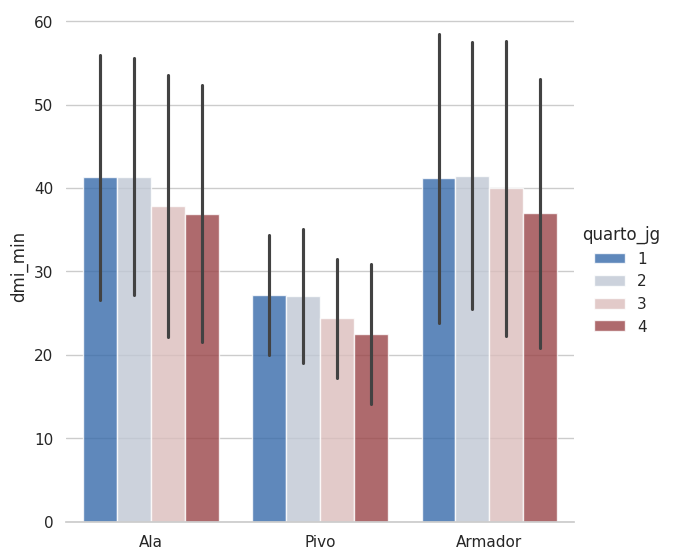

In [20]:
import seaborn as sns
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="bar",
    x="posicao", y="dmi_min", hue="quarto_jg",
    errorbar="sd", palette="vlag", alpha=.8, height=6
)
g.despine(left=True)
g.set_axis_labels("", "dmi_min")

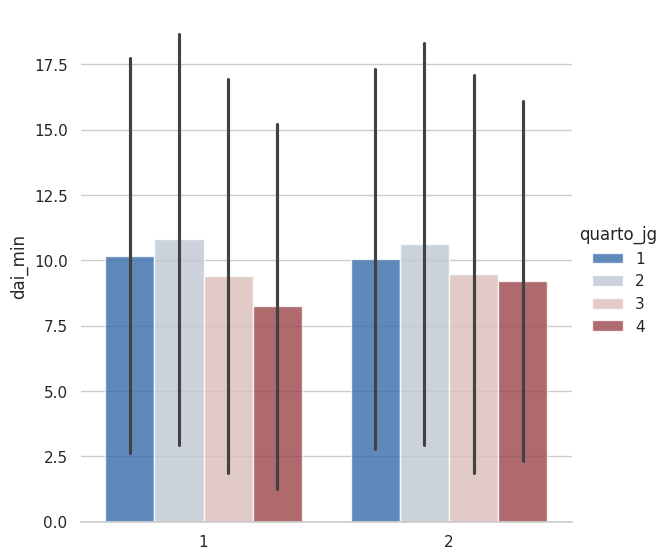

In [21]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="bar",
    x="mando", y="dai_min", hue="quarto_jg",
    errorbar="sd", palette="vlag", alpha=.8, height=6
)
g.despine(left=True)
g.set_axis_labels("", "dai_min")

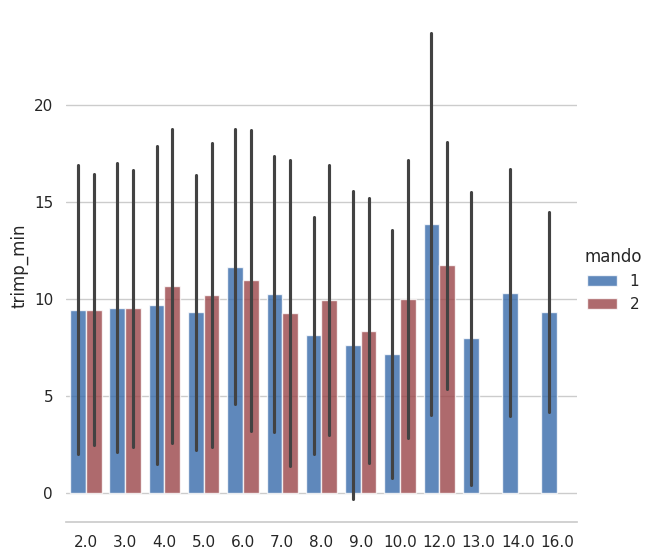

In [22]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="bar",
    x="interv_dias", y="dai_min", hue="mando",
    errorbar="sd", palette="vlag", alpha=.8, height=6
)
g.despine(left=True)
g.set_axis_labels("", "trimp_min")

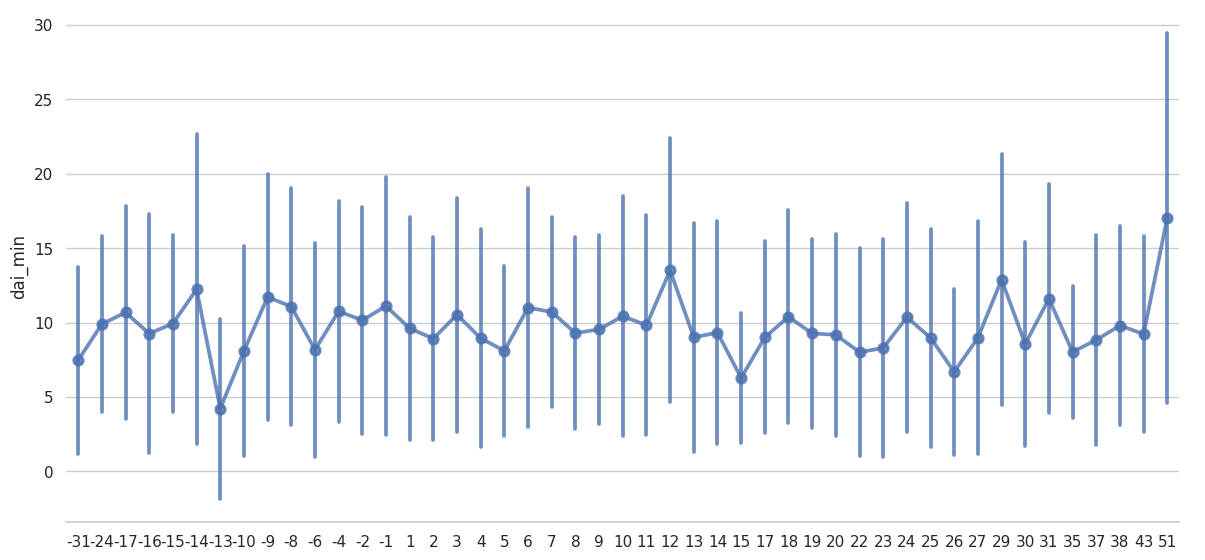

In [23]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="point",
    x="dif", y="dai_min",
    errorbar="sd", alpha=.8, height=6, aspect=2
)
g.despine(left=True)
g.set_axis_labels("", "dai_min")

In [24]:
# Se dif >= 1, vira 1. Se não, verifica se é <= -1 e vira 2.
# O que não encaixar (ex: 0.5) fica como NaN ou outro valor que você escolher.
dados_relat['win'] = np.where(dados_relat['dif'] >= 1, 1,
                             np.where(dados_relat['dif'] <= -1, 2, np.nan))

In [25]:
# Se 'dif' for maior que 6 OU menor que -6, recebe 1. Caso contrário, recebe 2.
dados_relat['desbalanceado'] = np.where((dados_relat['dif'] > 8) | (dados_relat['dif'] < -8), 1, 2)

In [26]:
dados_relat["desbalanceado"].value_counts()

,count
desbalanceado,
1,3029
2,1532


In [27]:
dados_relat["win"].value_counts()

,count
win,
1.0,3392
2.0,1169


/tmp/ipython-input-528/2221657526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


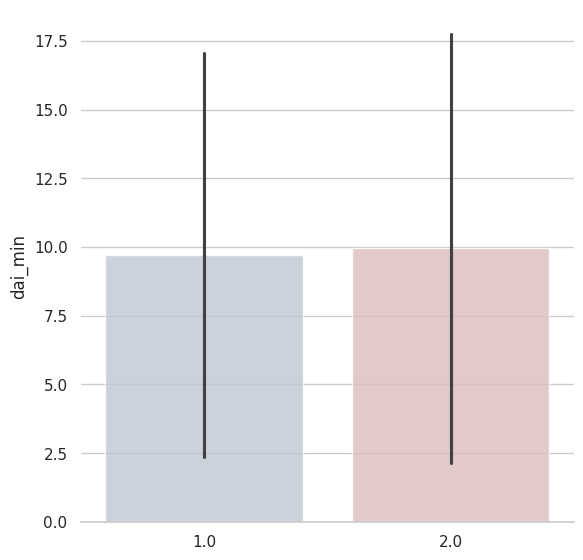

In [28]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="bar",
    x="win", y="dai_min",
    errorbar="sd", palette="vlag", alpha=.8, height=6
)
g.despine(left=True)
g.set_axis_labels("", "dai_min")

/tmp/ipython-input-528/1691146189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


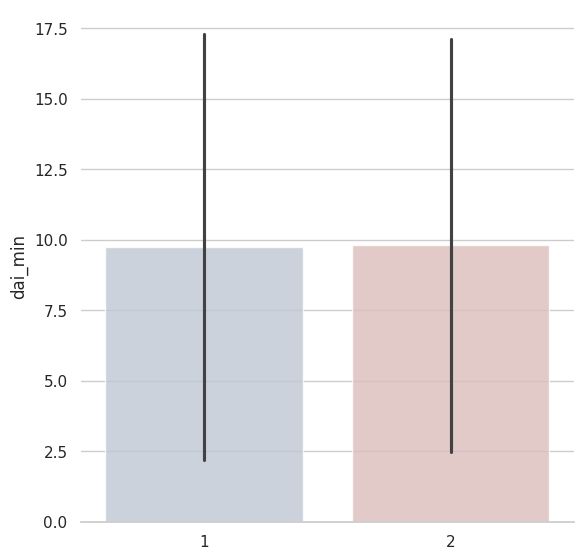

In [29]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="bar",
    x="desbalanceado", y="dai_min",
    errorbar="sd", palette="vlag", alpha=.8, height=6
)
g.despine(left=True)
g.set_axis_labels("", "dai_min")

In [30]:
dados_24 = dados_relat[dados_relat['temp'].isin(['24_25'])].copy()

In [31]:
dados_23 = dados_relat[dados_relat['temp'].isin(['23_24'])].copy()

In [32]:
dados_22 = dados_relat[dados_relat['temp'].isin(['22_23'])].copy()

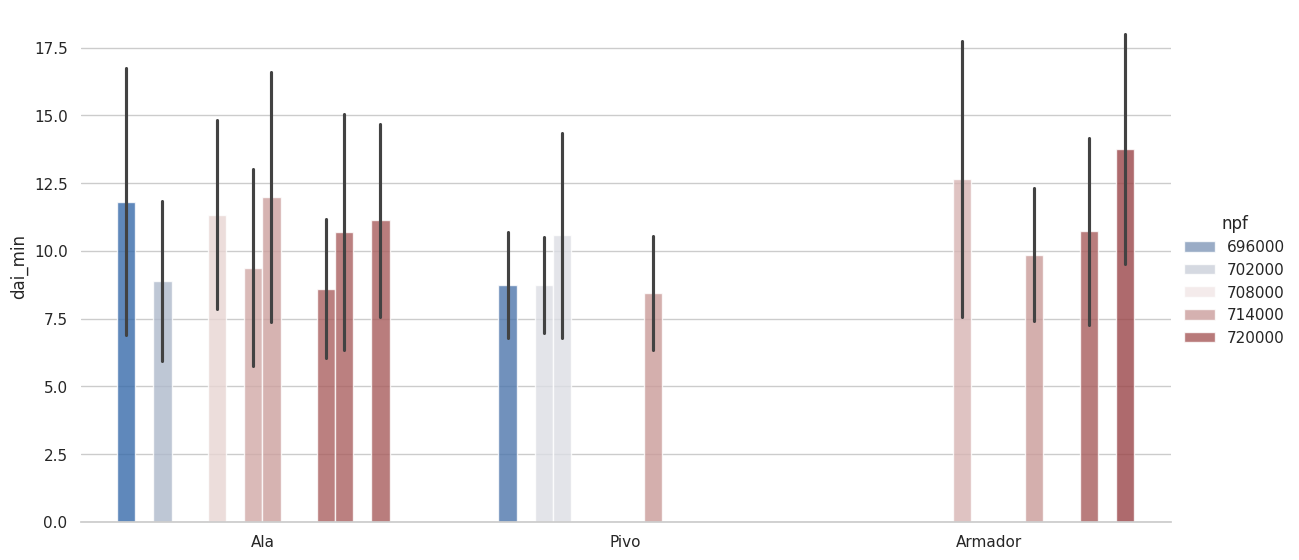

In [33]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_24, kind="bar",
    x="posicao", y="trimp_min", hue ="npf",
    errorbar="sd", palette="vlag", alpha=.8, height=6, aspect=2
)
g.despine(left=True)
g.set_axis_labels("", "dai_min")

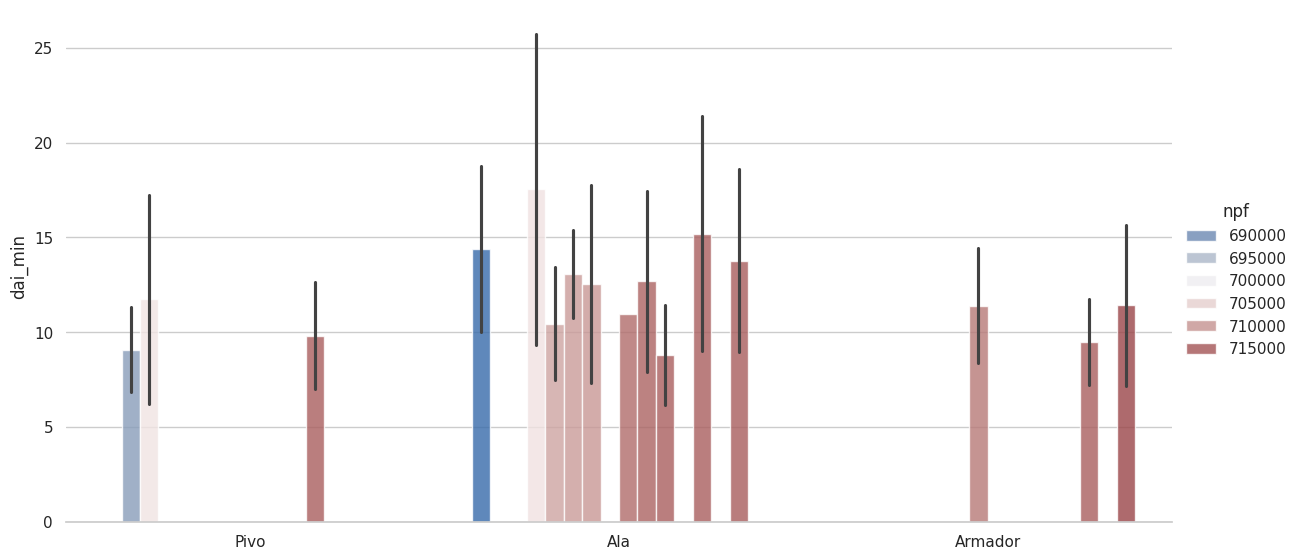

In [34]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_23, kind="bar",
    x="posicao", y="trimp_min", hue ="npf",
    errorbar="sd", palette="vlag", alpha=.8, height=6, aspect=2
)
g.despine(left=True)
g.set_axis_labels("", "dai_min")

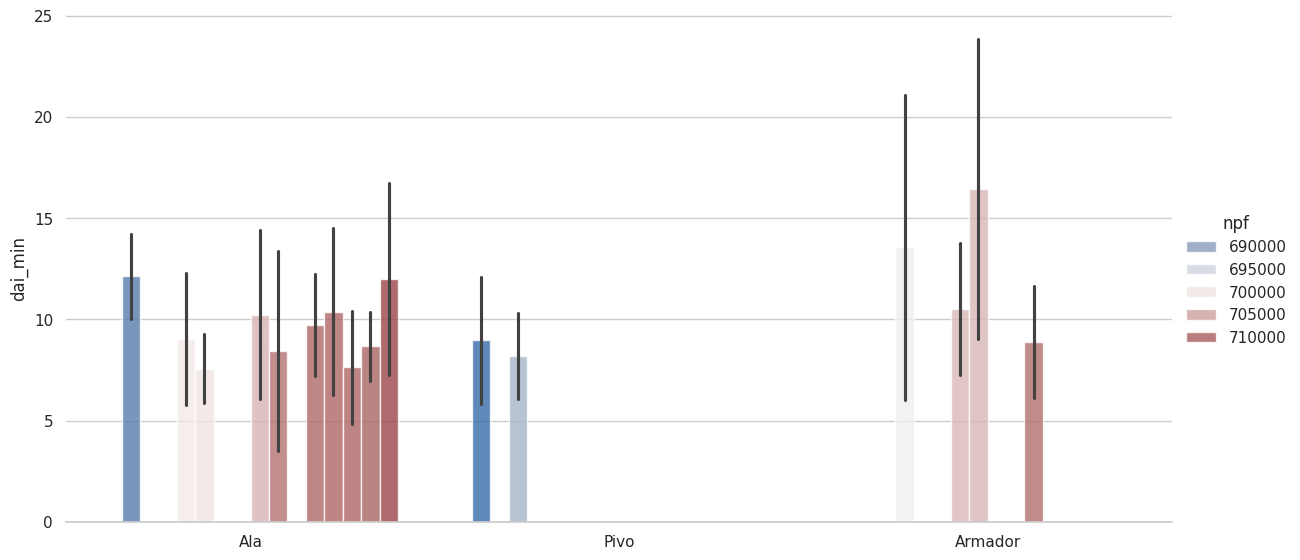

In [35]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_22, kind="bar",
    x="posicao", y="trimp_min", hue ="npf",
    errorbar="sd", palette="vlag", alpha=.8, height=6, aspect=2
)
g.despine(left=True)
g.set_axis_labels("", "dai_min")

In [36]:
dados_relat["idade"].describe()

,idade
count,4561.000000
mean,29.232624
std,4.786407
min,16.000000
25%,27.000000
50%,31.000000
75%,33.000000
max,37.000000


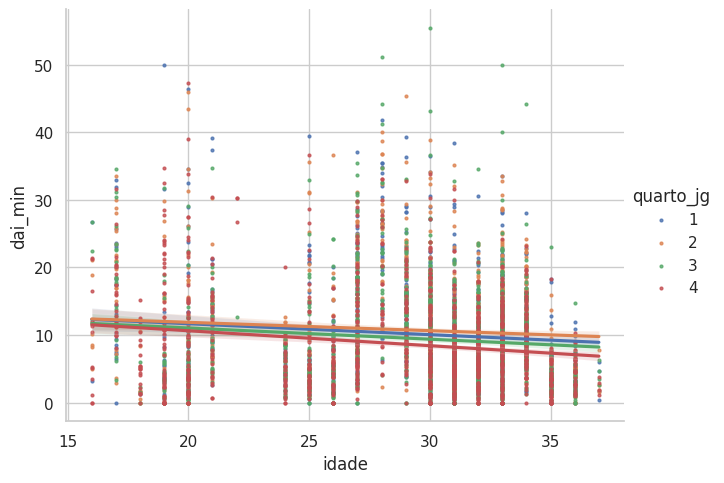

In [37]:
sns.set_theme(style="whitegrid")

# Plot sepal width as a function of sepal_length across days
g = sns.lmplot(
    data=dados_relat,
    x="idade", y="dai_min", hue="quarto_jg",
                palette="deep", scatter_kws={"s": 4},
    height=5, aspect=1.3,
)

# Use more informative axis labels than are provided by default
g.set_axis_labels("idade", "dai_min")

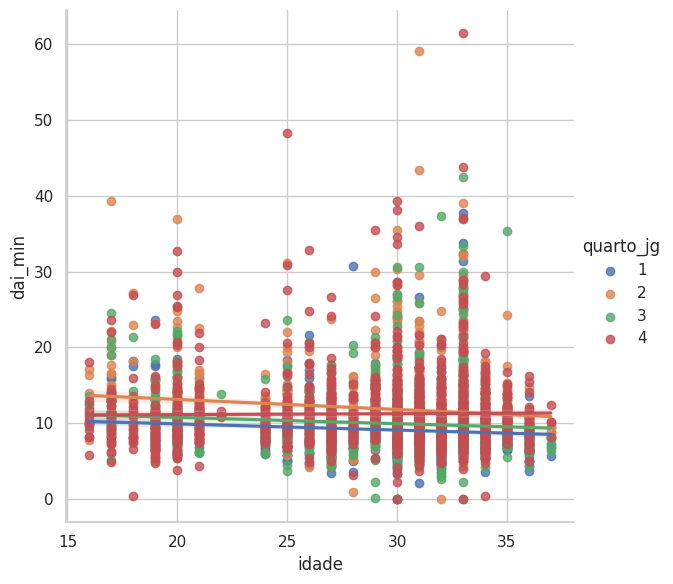

In [38]:
sns.set_theme(style="whitegrid")

# Plot sepal width as a function of sepal_length across days
g = sns.lmplot(
    data=dados_relat,
    x="idade", y="trimp_min", hue="quarto_jg",
                palette="deep",
    height=6
)

# Use more informative axis labels than are provided by default
g.set_axis_labels("idade", "dai_min")

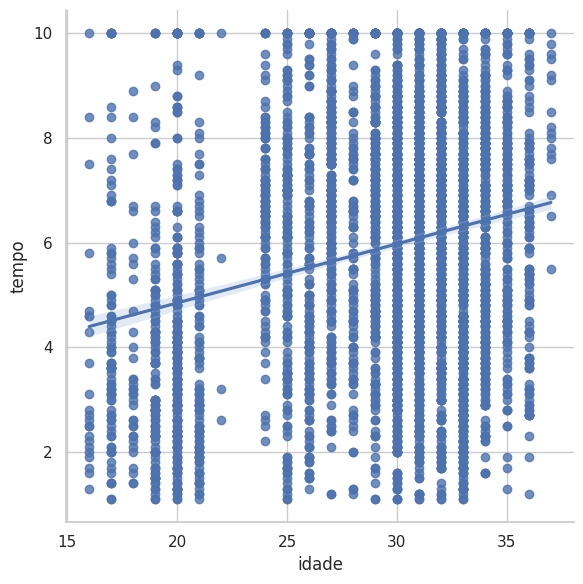

In [39]:
sns.set_theme(style="whitegrid")

# Plot sepal width as a function of sepal_length across days
g = sns.lmplot(
    data=dados_relat,
    x="idade", y="tempo",
                palette="deep",
    height=6
)

# Use more informative axis labels than are provided by default
g.set_axis_labels("idade", "tempo")

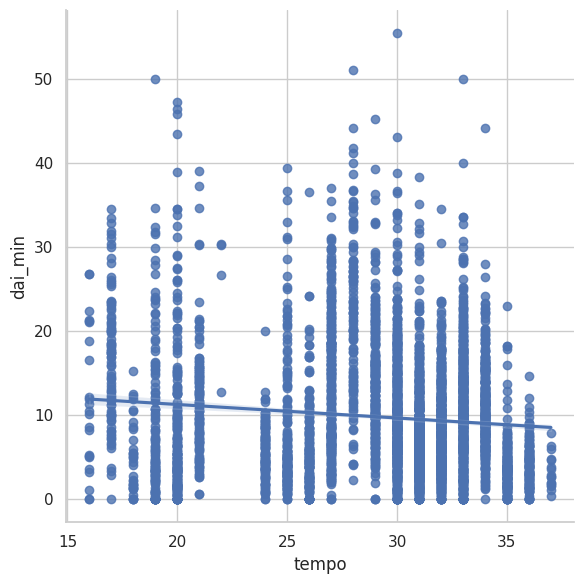

In [40]:
sns.set_theme(style="whitegrid")

# Plot sepal width as a function of sepal_length across days
g = sns.lmplot(
    data=dados_relat,
    x="idade", y="dai_min",
                palette="deep",
    height=6
)

# Use more informative axis labels than are provided by default
g.set_axis_labels("tempo", "dai_min")

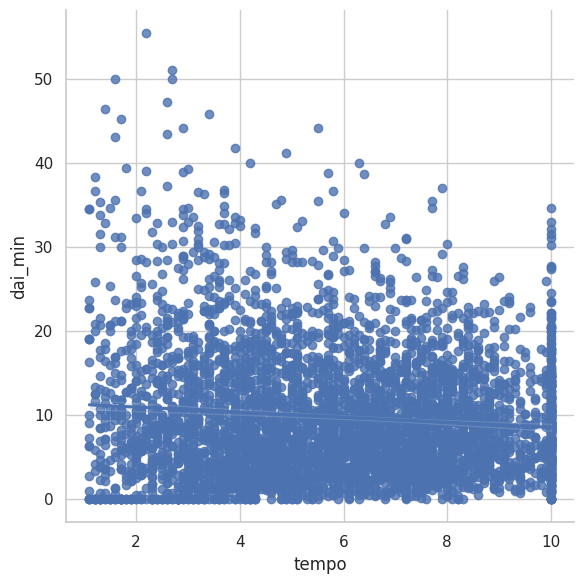

In [41]:
sns.set_theme(style="whitegrid")

# Plot sepal width as a function of sepal_length across days
g = sns.lmplot(
    data=dados_relat,
    x="tempo", y="dai_min",
                palette="deep",
    height=6
)

# Use more informative axis labels than are provided by default
g.set_axis_labels("tempo", "dai_min")

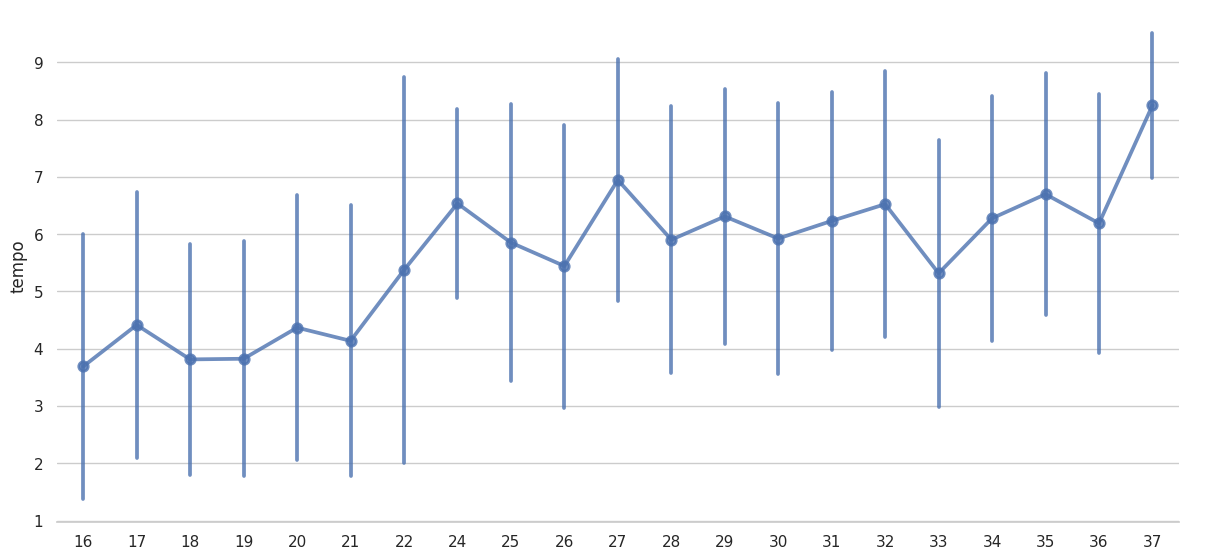

In [42]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="point",
    x="idade", y="tempo",
    errorbar="sd", alpha=.8, height=6, aspect=2
)
g.despine(left=True)
g.set_axis_labels("", "tempo")

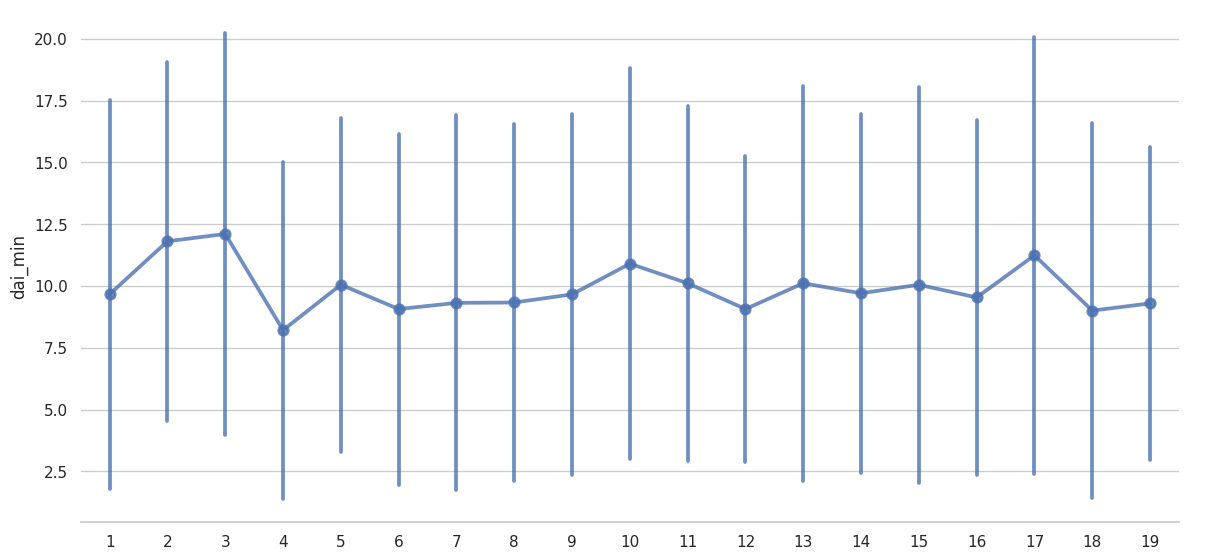

In [43]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="point",
    x="classificacao", y="dai_min",
    errorbar="sd", alpha=.8, height=6, aspect=2
)
g.despine(left=True)
g.set_axis_labels("", "dai_min")

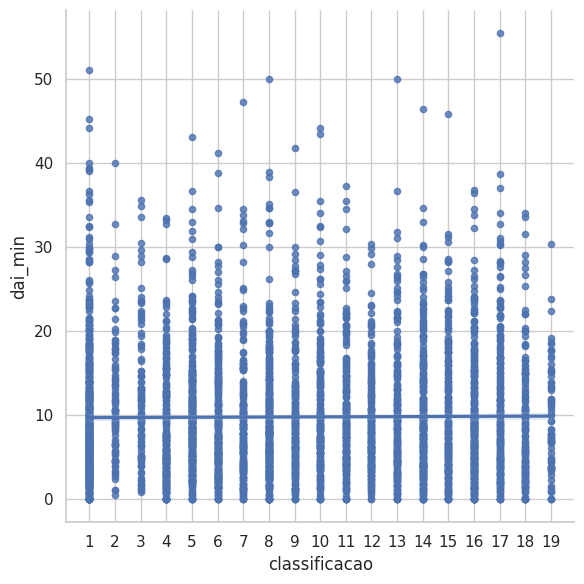

In [44]:
import numpy as np
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

g = sns.lmplot(
    data=dados_relat,
    x="classificacao", y="dai_min",
    palette="deep",
    height=6,
    scatter_kws={"s": 20} # Aproveitando a dica anterior para os pontos
)

# Definindo o intervalo de 1 em 1
# Pegamos o valor mínimo e máximo da coluna para criar a sequência
min_x = int(dados_relat["classificacao"].min())
max_x = int(dados_relat["classificacao"].max())

# g.ax.set_xticks define a posição dos números no eixo X
g.ax.set_xticks(np.arange(min_x, max_x + 1, 1))

g.set_axis_labels("classificacao", "dai_min")

plt.show()

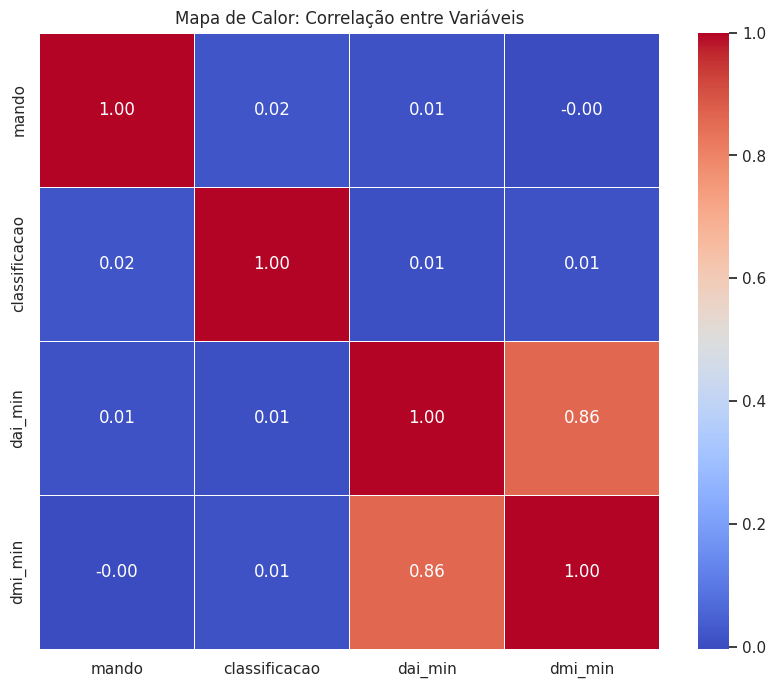

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtrando apenas as variáveis desejadas
colunas_interesse = ['mando', 'classificacao', 'dai_min', 'dmi_min']
df_corr = dados_relat[colunas_interesse]

# 2. Calculando a matriz de correlação (Pearson por padrão)
corr_matrix = df_corr.corr()

# 3. Configurando o visual do gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,      # Mostra os valores dentro dos quadrados
            fmt=".2f",       # Formata para 2 casas decimais
            cmap='coolwarm', # Escala de cor: azul (negativa) a vermelho (positiva)
            linewidths=0.5)

plt.title('Mapa de Calor: Correlação entre Variáveis')
plt.show()

In [46]:
dados_relat['posicao'].value_counts()

,count
posicao,
Ala,2393
Pivo,1142
Armador,1026


In [47]:
dados_relat['temp'].value_counts()

,count
temp,
23_24,1644
24_25,1601
22_23,1316


In [48]:
dados_relat.groupby('temp')['nome_sessao'].nunique()

,nome_sessao
temp,
22_23,41
23_24,47
24_25,47


In [49]:
dados_relat.groupby('posicao')['npf'].nunique()

,npf
posicao,
Ala,19
Armador,9
Pivo,5


In [50]:
dados_relat.groupby(['temp'])['npf'].nunique()

,npf
temp,
22_23,16
23_24,16
24_25,16


In [51]:
dados_relat['npf'].nunique()

33

In [52]:
dados_relat['quarto_jg'].value_counts()

,count
quarto_jg,
2,1162
1,1158
3,1138
4,1103


In [53]:
dados_relat['idade'].agg(Media='max', Desvio='std').round(1)

,idade
Media,37.0
Desvio,4.8


/tmp/ipython-input-528/2624981077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


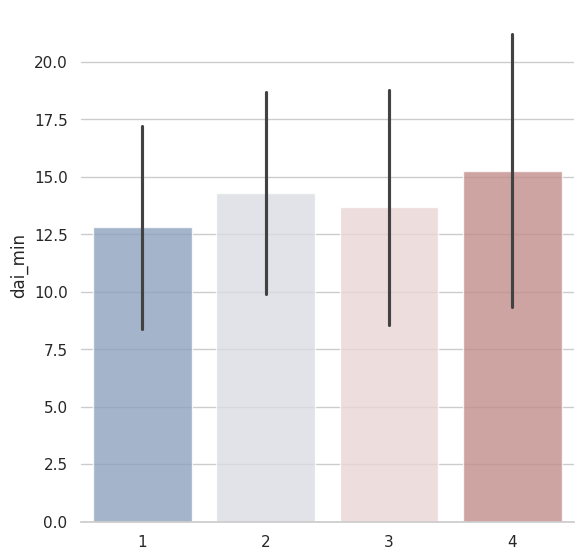

In [54]:
sns.set_theme(style="whitegrid")


g = sns.catplot(
    data=dados_relat, kind="bar",
    x="quarto_jg", y="acel2_min",
    errorbar="sd", palette="vlag", alpha=.8, height=6
)
g.despine(left=True)
g.set_axis_labels("", "dai_min")

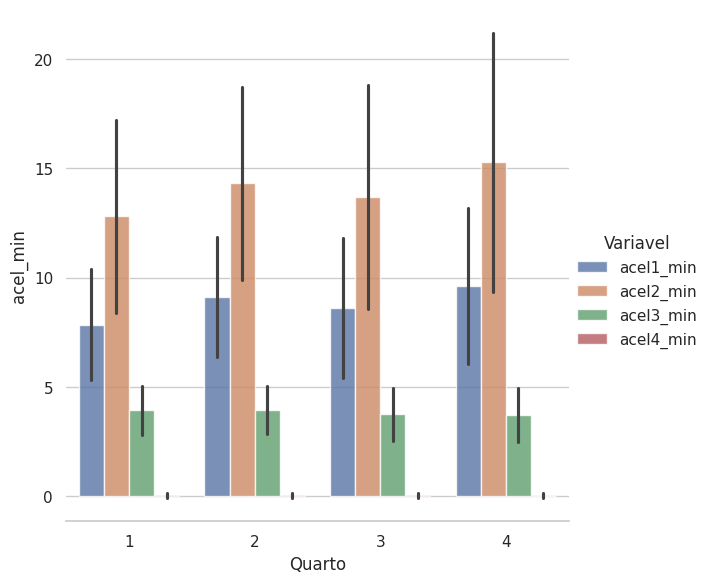

In [55]:
# Usamos o mesmo DataFrame 'dados_longo' da opção anterior
# Primeiro, precisamos "derreter" o DataFrame para o formato longo (long-form)
dados_longo = dados_relat.melt(id_vars="quarto_jg", value_vars=["acel1_min", "acel2_min", "acel3_min", "acel4_min"],
                               var_name="Variavel", value_name="Valor")
g = sns.catplot(
    data=dados_longo, kind="bar",
    x="quarto_jg", y="Valor", hue="Variavel",  # O 'hue' separa as cores das variáveis
    errorbar="sd", alpha=.8, height=6
)
g.despine(left=True)
g.set_axis_labels("Quarto", "acel_min")

In [56]:
def formatar_media_std(x):
    # Calcula a média e desvio, tratando os valores individualmente
    m = x.mean()
    s = x.std()
    # Formata com 1 casa decimal dentro da string (f-string)
    return f"{m:.1f} ± {s:.1f}"

# Aplica o agrupamento
relatorio_final = (
dados_relat.groupby('quarto_jg')[['dits_total_min', 'zv3_min', 'dmi_min', 'dai_min']].agg(formatar_media_std)
)

print(relatorio_final)

          dits_total_min      zv3_min      dmi_min     dai_min
quarto_jg                                                     
1           156.6 ± 31.4   27.6 ± 9.5  37.7 ± 15.2  10.1 ± 7.4
2           174.3 ± 34.5   27.1 ± 9.0  37.8 ± 14.8  10.7 ± 7.8
3           160.9 ± 43.4  25.5 ± 10.0  34.9 ± 15.8   9.4 ± 7.6
4           170.7 ± 42.8  24.7 ± 10.1  33.4 ± 15.5   8.7 ± 6.9


In [57]:
def formatar_media_std(x):
    # Calcula a média e desvio, tratando os valores individualmente
    m = x.mean()
    s = x.std()
    # Formata com 1 casa decimal dentro da string (f-string)
    return f"{m:.1f} ± {s:.1f}"

# Aplica o agrupamento
relatorio_final = (
dados_relat.groupby('quarto_jg')[['ac_total_min', 'acel2_min', 'acmi_min', 'aci_min']].agg(formatar_media_std)
)

print(relatorio_final)

          ac_total_min   acel2_min    acmi_min    aci_min
quarto_jg                                                
1           24.6 ± 6.5  12.8 ± 4.4  16.8 ± 4.9  4.0 ± 1.1
2           27.4 ± 6.4  14.3 ± 4.4  18.3 ± 4.7  4.0 ± 1.1
3           26.1 ± 8.2  13.7 ± 5.1  17.5 ± 5.7  3.8 ± 1.2
4           28.6 ± 9.1  15.3 ± 5.9  19.0 ± 6.4  3.8 ± 1.2


In [58]:
def formatar_media_std(x):
    # Calcula a média e desvio, tratando os valores individualmente
    m = x.mean()
    s = x.std()
    # Formata com 1 casa decimal dentro da string (f-string)
    return f"{m:.1f} ± {s:.1f}"

# Aplica o agrupamento
relatorio_final = (
dados_relat.groupby('quarto_jg')[['dc_total_min', 'dcel2_min', 'dcmi_min', 'dci_min']].agg(formatar_media_std)
)

print(relatorio_final)

          dc_total_min   dcel2_min    dcmi_min    dci_min
quarto_jg                                                
1           25.5 ± 6.6  12.7 ± 4.6  17.1 ± 5.1  4.4 ± 1.2
2           28.1 ± 6.5  14.3 ± 4.3  18.8 ± 4.8  4.6 ± 1.2
3           26.8 ± 8.1  13.5 ± 5.0  17.8 ± 5.8  4.4 ± 1.3
4           29.3 ± 8.9  15.2 ± 5.9  19.7 ± 6.6  4.5 ± 1.4


In [59]:
def formatar_media_std(x):
    # Calcula a média e desvio, tratando os valores individualmente
    m = x.mean()
    s = x.std()
    # Formata com 1 casa decimal dentro da string (f-string)
    return f"{m:.1f} ± {s:.1f}"

# Aplica o agrupamento
relatorio_final = (
dados_relat.groupby('quarto_jg')[['trimp_min']].agg(formatar_media_std)
)

print(relatorio_final)

            trimp_min
quarto_jg            
1           9.1 ± 3.5
2          11.9 ± 4.8
3          10.0 ± 4.0
4          11.2 ± 5.1
